In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from utils import set_seed

globals_seed = set_seed(42)

num_dim = 2
num_discrete_values = 8
num_qubits = num_dim * int(np.log2(num_discrete_values))

print(f"Number of qubits: {num_qubits}")

Number of qubits: 6


In [2]:
from scipy.stats import multivariate_normal

coords = np.linspace(-2, 2, num_discrete_values)
print(f"Coordinates: {coords.shape}, {coords}")

rv = multivariate_normal(mean=[0.0, 0.0], cov=[[1, 0], [0, 1]], seed=globals_seed)

grid_elements = np.transpose([np.tile(coords, len(coords)), np.repeat(coords, len(coords))])
print("x values :", grid_elements.shape, grid_elements)

prob_data = rv.pdf(grid_elements)
print("pdf values :", prob_data)

total_prob = np.sum(prob_data)
prob_data = prob_data / total_prob
print("pdf values :", prob_data)

Coordinates: (8,), [-2.         -1.42857143 -0.85714286 -0.28571429  0.28571429  0.85714286
  1.42857143  2.        ]
x values : (64, 2) [[-2.         -2.        ]
 [-1.42857143 -2.        ]
 [-0.85714286 -2.        ]
 [-0.28571429 -2.        ]
 [ 0.28571429 -2.        ]
 [ 0.85714286 -2.        ]
 [ 1.42857143 -2.        ]
 [ 2.         -2.        ]
 [-2.         -1.42857143]
 [-1.42857143 -1.42857143]
 [-0.85714286 -1.42857143]
 [-0.28571429 -1.42857143]
 [ 0.28571429 -1.42857143]
 [ 0.85714286 -1.42857143]
 [ 1.42857143 -1.42857143]
 [ 2.         -1.42857143]
 [-2.         -0.85714286]
 [-1.42857143 -0.85714286]
 [-0.85714286 -0.85714286]
 [-0.28571429 -0.85714286]
 [ 0.28571429 -0.85714286]
 [ 0.85714286 -0.85714286]
 [ 1.42857143 -0.85714286]
 [ 2.         -0.85714286]
 [-2.         -0.28571429]
 [-1.42857143 -0.28571429]
 [-0.85714286 -0.28571429]
 [-0.28571429 -0.28571429]
 [ 0.28571429 -0.28571429]
 [ 0.85714286 -0.28571429]
 [ 1.42857143 -0.28571429]
 [ 2.         -0.28571429]

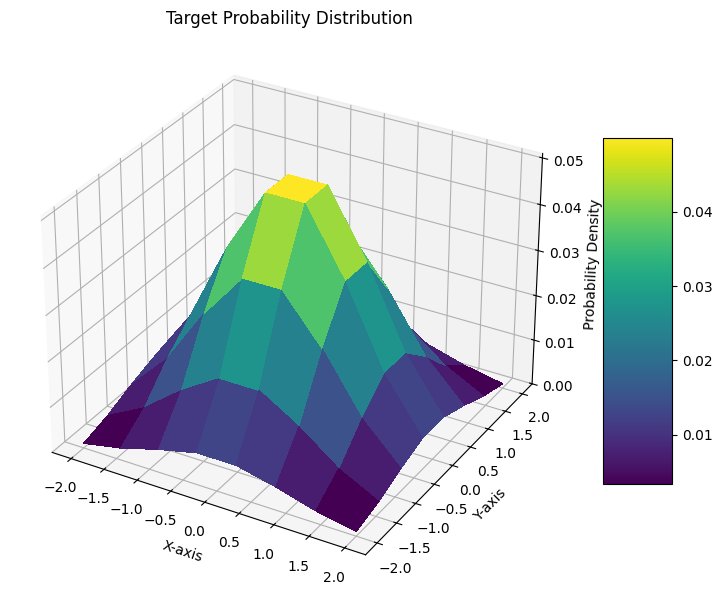

In [3]:
import matplotlib.pyplot as plt
from matplotlib import cm

mesh_x, mesh_y = np.meshgrid(coords, coords)
grid_shape = (num_discrete_values, num_discrete_values)

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "3d"})
prob_grid = np.reshape(prob_data, grid_shape)
surf = ax.plot_surface(
    mesh_x, mesh_y, prob_grid, cmap=cm.viridis, linewidth=0, antialiased=False
)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.title("Target Probability Distribution")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
ax.set_zlabel("Probability Density")
plt.show()

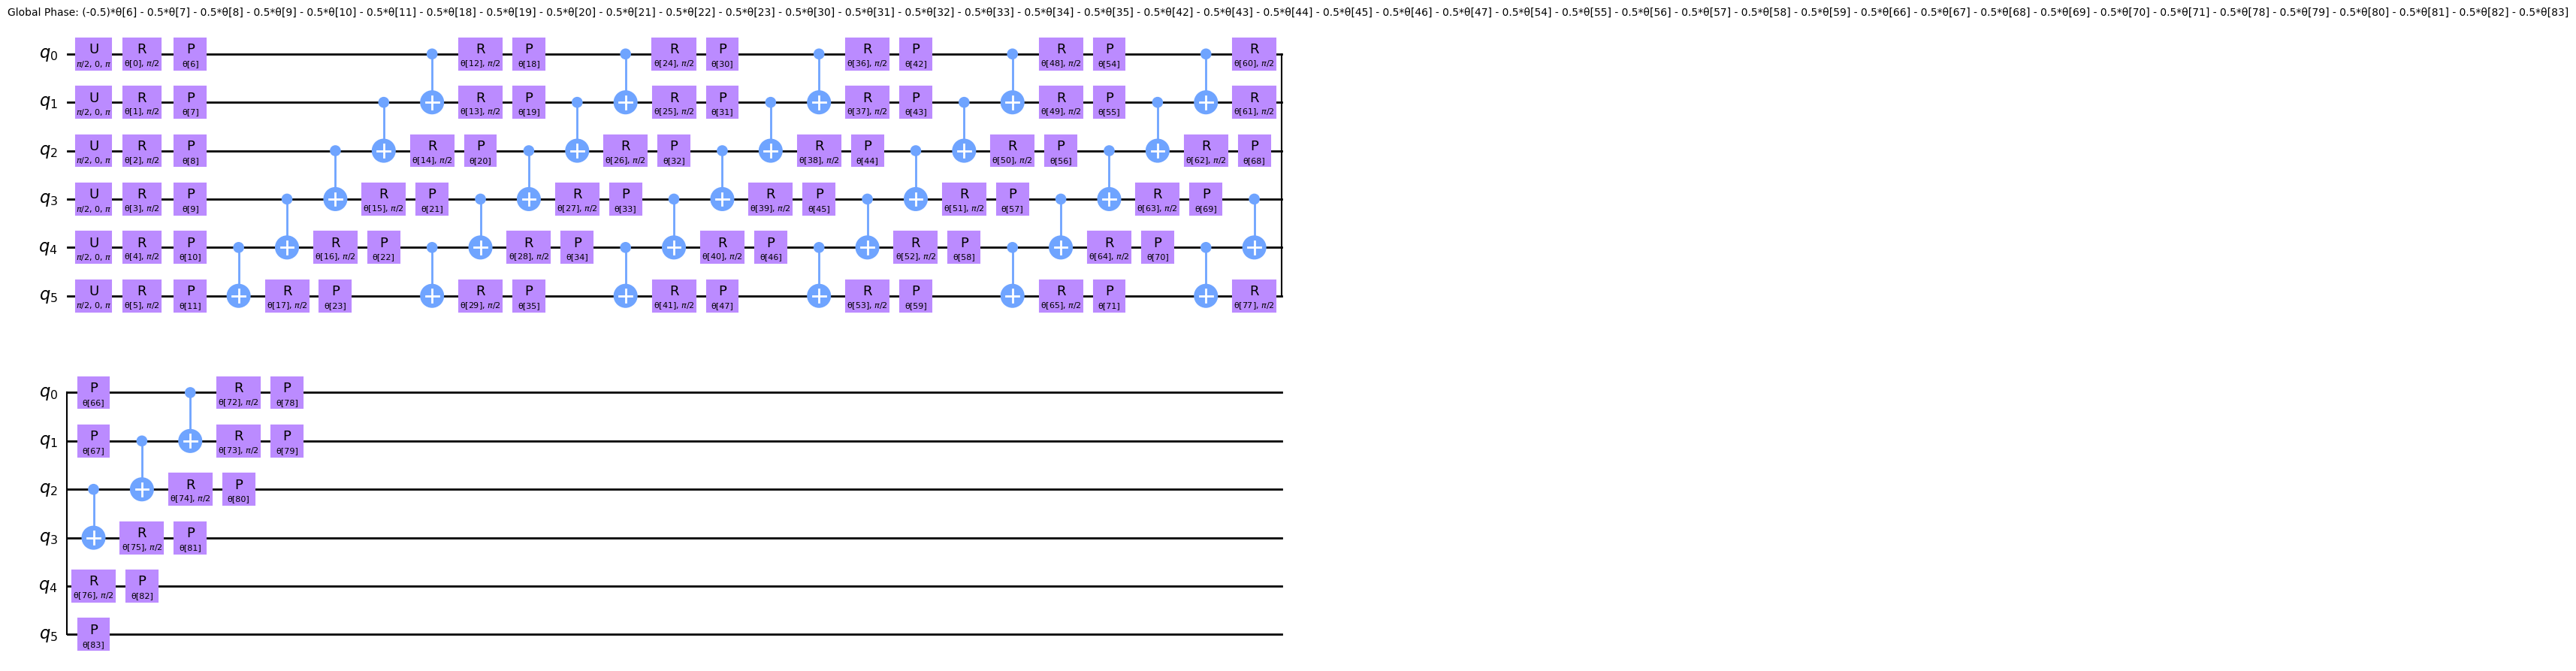

In [4]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import efficient_su2

qc = QuantumCircuit(num_qubits)
qc.h(qc.qubits)

ansatz = efficient_su2(num_qubits, reps=6)
qc.compose(ansatz, inplace=True)

qc.decompose().draw(output="mpl", style="clifford")

In [ ]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()